In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Optionally, you can print more details about the GPU if available
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs available: {torch.cuda.device_count()}")

Using device: cuda
GPU Name: Tesla T4
Number of GPUs available: 1


In [ ]:

class STN1D(nn.Module):
    def __init__(self, input_size):
        """
        A simple Spatial Transformer for 1D signals.
        Args:
            input_size (int): Number of features (length of the spectrum).
        """
        super(STN1D, self).__init__()
        self.localization = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(True),
            nn.Linear(64, 32),
            nn.ReLU(True),
            nn.Linear(32, 2)  
        )

        # Initialize the last layer to predict the identity transform.
        self.localization[-1].weight.data.zero_()
        self.localization[-1].bias.data.copy_(torch.tensor([1.0, 0.0], dtype=torch.float))

    def forward(self, x):
        """
        Args:
            x (Tensor): shape (B, input_size)
        Returns:
            x_transformed (Tensor): spatially transformed input, shape (B, input_size)
            theta (Tensor): the affine transformation matrices, shape (B, 2, 3)
        """
        B, input_size = x.size()
        # Predict affine transform parameters.
        theta_params = self.localization(x)  # (B, 2)
        # Extract scale and translation for x-axis.
        a = theta_params[:, 0].unsqueeze(1)  # scaling
        t = theta_params[:, 1].unsqueeze(1)  # translation

        # Build a 2x3 affine transformation matrix.
        # We keep the second row fixed to [0, 1, 0] so that only horizontal adjustments occur.
        theta = torch.cat([a, torch.zeros_like(a), t,
                           torch.zeros_like(a), torch.ones_like(a), torch.zeros_like(a)], dim=1)
        theta = theta.view(-1, 2, 3)  # shape (B, 2, 3)

        # Reshape input x to 4D tensor: (B, C, H, W) where H=1 and W=input_size.
        x_reshaped = x.unsqueeze(1).unsqueeze(2)
        grid = F.affine_grid(theta, x_reshaped.size(), align_corners=False)
        x_transformed = F.grid_sample(x_reshaped, grid, align_corners=False)
        # Squeeze out the extra dimensions to revert back to shape (B, input_size).
        x_transformed = x_transformed.squeeze(1).squeeze(1)
        return x_transformed, theta

class MultiClassifierV2_STN(nn.Module):
    def __init__(self, input_features=6601, output_features=40):
        """
        A neural network for XPS spectra classification that first applies a Spatial Transformer
        to automatically align the spectrum, then passes the aligned input through fully connected layers.
        Args:
            input_features (int): Length of input 1D spectrum.
            output_features (int): Number of output classes.
        """
        super(MultiClassifierV2_STN, self).__init__()
        # Add the STN module.
        self.stn = STN1D(input_size=input_features)
        
        # The main classifier layers.
        self.layer_1 = nn.Linear(input_features, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.layer_2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.layer_3 = nn.Linear(128, output_features)
        
        self.activation = nn.LeakyReLU(negative_slope=0.01)
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, x):
        # First, apply the STN to align the input spectrum.
        x_aligned, theta = self.stn(x)
        
        # Pass the aligned spectrum through the classification layers.
        x_out = self.activation(self.bn1(self.layer_1(x_aligned)))
        x_out = self.dropout(x_out)
        x_out = self.activation(self.bn2(self.layer_2(x_out)))
        x_out = self.dropout(x_out)
        x_out = self.layer_3(x_out)  # Output layer (logits)
        
        # --- CHANGE THIS LINE ---
        # Original: return x
        # New: return both the final output and the aligned spectrum
        return x_out, x_aligned

In [8]:
def apply_horizontal_shift(spectrum, max_shift):
    '''
    Applies a random horizontal shift to the entire spectrum sequence.
    Args:
        spectrum
        max_shift: maximum number of indices by which the data can shift (set to zero for no shift allowed)
    Returns:
        shifted_spectrum
    '''
    shift = random.randint(-max_shift, max_shift)
    # Create an array of zeros with the same length as the original spectrum
    shifted_spectrum = np.zeros_like(spectrum)

    if shift > 0:
        # Shift to the right
        shifted_spectrum[shift:] = spectrum[:-shift]
    elif shift < 0:
        # Shift to the left
        shifted_spectrum[:shift] = spectrum[-shift:]
    else:
        # No shift, return the original spectrum
        shifted_spectrum = spectrum.copy()

    shifted_spectrum = shifted_spectrum[:len(spectrum)]
    return shifted_spectrum


In [4]:
import torch

# Load the entire dictionary object
test_data = torch.load('../data/synthetic_data_hard_final/test_data.pt')

# Access each item by its key
X_test = test_data['features']
y_test = test_data['labels']


# Now you can use these tensors for evaluation
print(f"Loaded features shape: {X_test.shape}")
print(f"Loaded labels shape: {y_test.shape}")

# If you need a DataLoader for batching during evaluation:
from torch.utils.data import TensorDataset, DataLoader

test_dataset = TensorDataset(X_test, y_test)
test_loader_new = DataLoader(test_dataset, batch_size=64, shuffle=False)

Loaded features shape: torch.Size([20000, 6601])
Loaded labels shape: torch.Size([20000, 40])


In [5]:
# ✅ Correct import
from pathlib import Path

# 4. Create an instance of the model and send it to target device
model_0 = MultiClassifierV2_STN().to(device)

# Load the saved model
model_path = Path("../../../local_models/STN_3_shift.pth")


model_0.load_state_dict(torch.load(model_path))
model_0.eval()

MultiClassifierV2_STN(
  (stn): STN1D(
    (localization): Sequential(
      (0): Linear(in_features=6601, out_features=64, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=64, out_features=32, bias=True)
      (3): ReLU(inplace=True)
      (4): Linear(in_features=32, out_features=2, bias=True)
    )
  )
  (layer_1): Linear(in_features=6601, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer_2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer_3): Linear(in_features=128, out_features=40, bias=True)
  (activation): LeakyReLU(negative_slope=0.01)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [6]:
# Ensure your model and data are on the correct device
model_0.to(device)
X_test = X_test.to(device)

# Store the original and aligned spectra
original_spectra = X_test
aligned_spectra_list = []

# Generate predictions and capture the aligned spectra
with torch.inference_mode():
    # Unpack the tuple returned by the model
    test_logits_raw, aligned_spectra = model_0(original_spectra)
    
    # Process the outputs as before
    test_logits = test_logits_raw.squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

print("✅ Captured aligned spectra from the STN.")

✅ Captured aligned spectra from the STN.


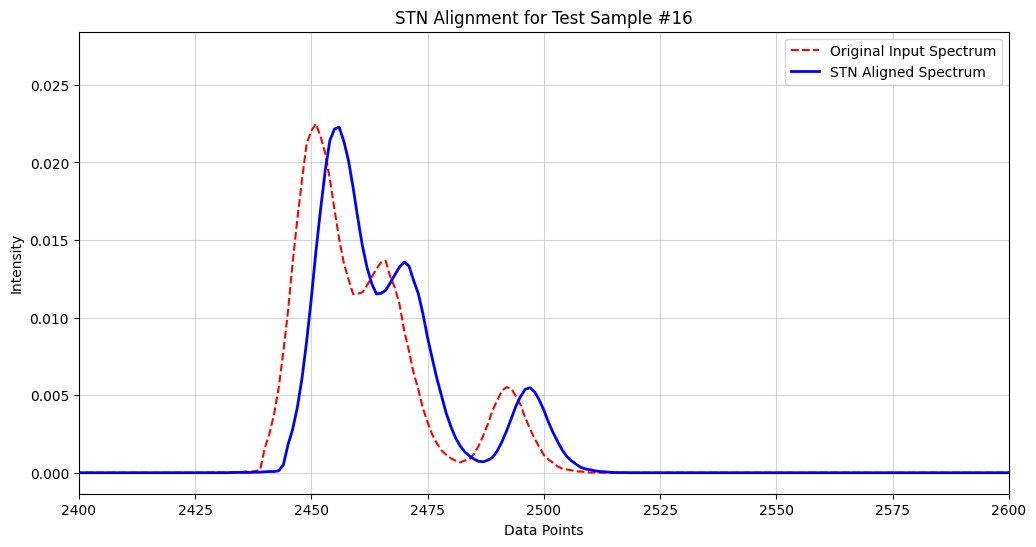

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Choose an index to inspect
index = 16

# Retrieve the specific spectra from your tensors
# Move them to the CPU and convert to NumPy for plotting
original_spec = original_spectra[index].cpu().numpy()
aligned_spec = aligned_spectra[index].cpu().numpy()

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(original_spec, label='Original Input Spectrum', color='red', linestyle='--')
plt.plot(aligned_spec, label='STN Aligned Spectrum', color='blue', linewidth=2)
plt.title(f"STN Alignment for Test Sample #{index}")
plt.xlabel("Data Points")
plt.ylabel("Intensity")
plt.legend()
plt.xlim(2400,2600)
plt.grid(True, alpha=0.5)
plt.show()